In [1]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
plt.rcParams["figure.figsize"] = (24,18)

from cv_utils import *
from pitch_segmentation import *

import albumentations

### Load data

[[2560    0]
 [2560 1440]
 [   0 1440]
 [   0    0]]


array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

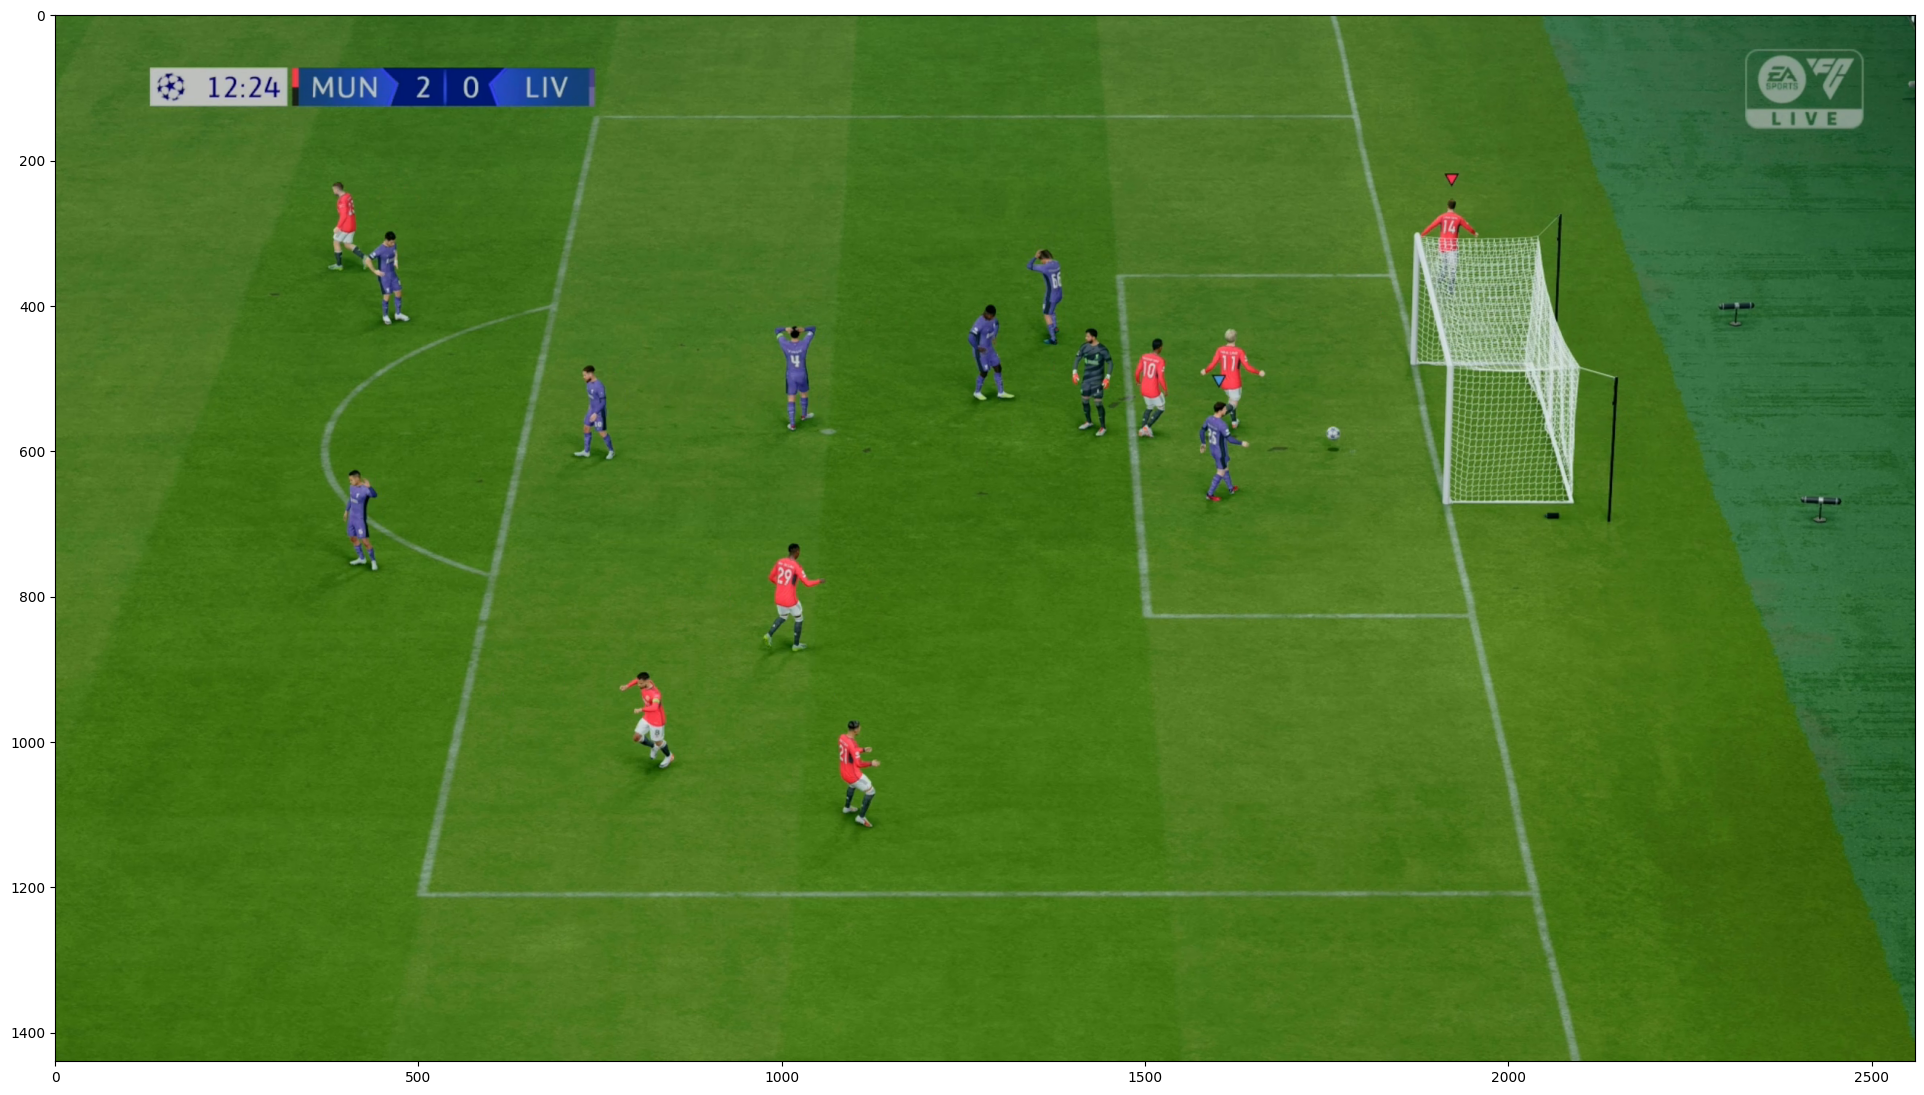

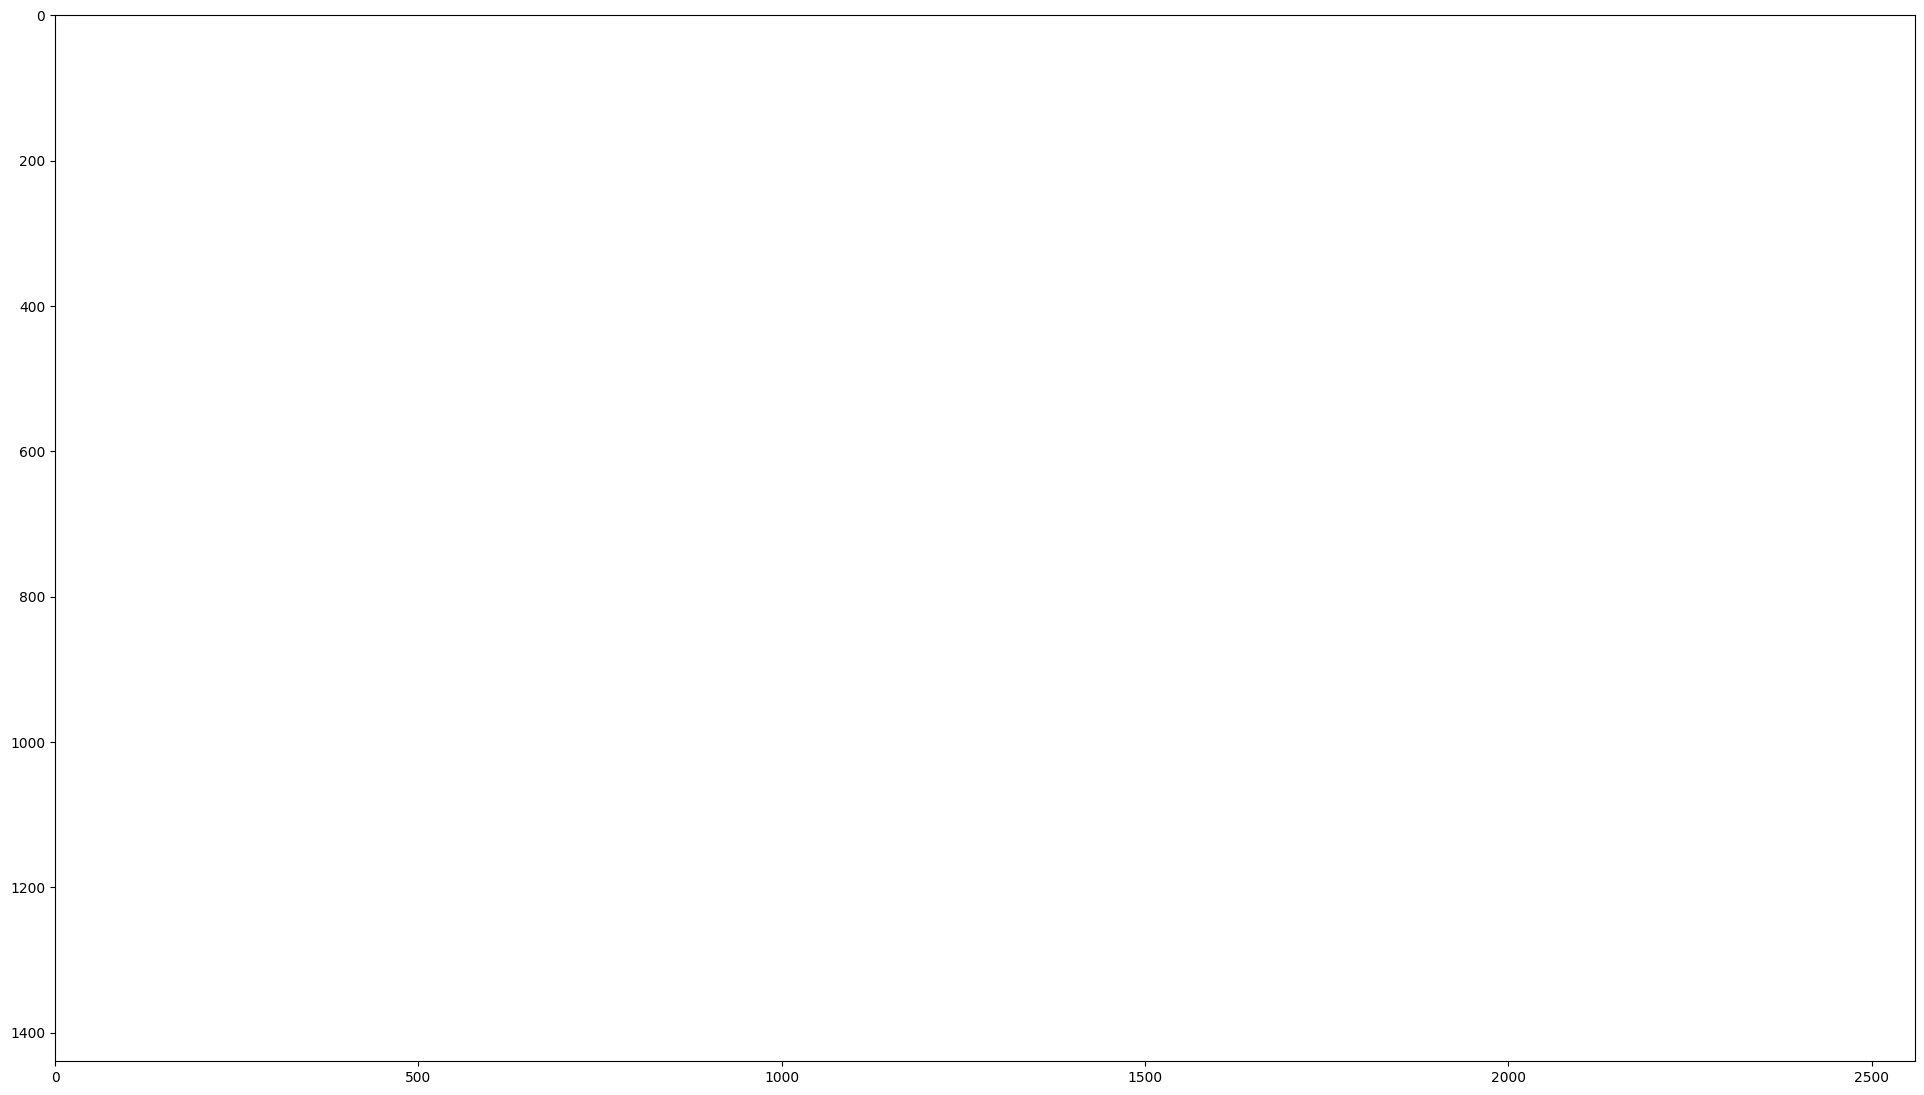

In [2]:
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
merge_dest_path = os.path.join(data_path, 'coco_datasets/real_synth_train_pitch')

image_folder = os.path.join(merge_dest_path, "images")
annotation_file = os.path.join(merge_dest_path, "annotations", "instances_default.json")

with open(annotation_file, 'r') as f:
    annotations = json.load(f)

image_id = 517
image_name = [image_info["file_name"] for image_info in annotations['images']
                                        if image_info['id'] == image_id][0]
annotation_list = [annotation 
                    for annotation in annotations['annotations']
                    if annotation['image_id'] == image_id][0]

image_path = os.path.join(image_folder, image_name)
image = cv2.cvtColor(cv2.imread(image_path, 
                                        cv2.IMREAD_UNCHANGED), cv2.COLOR_BGR2RGB)
plt.figure()
plt.imshow(image)

annotation = np.array(annotation_list['segmentation'][0], 
                                dtype=np.int32).reshape((-1, 2))
print(annotation)
mask = np.zeros(image.shape[:2], dtype=np.uint8)
cv2.fillPoly(mask, [annotation], color=255)
plt.figure()
plt.imshow(mask, cmap='gray', vmin=0, vmax=255)
mask

In [3]:
merge = False
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
coco_dataset_path_1 = os.path.join(data_path, 'coco_datasets/real_train_pitch')
coco_dataset_path_2 = os.path.join(data_path, 'coco_datasets/synth_train_pitch')
if merge:
    dest_path=os.path.join(data_path, 'coco_datasets')
    merge_dest_path = merge_coco_dataset(coco_dataset_path_1, coco_dataset_path_2,
                    dest_path=os.path.join(data_path, 'coco_datasets'))
else:
    merge_dest_path = os.path.join(data_path, 'coco_datasets/real_synth_train_pitch')

000000000141.png
000000000137_dup.png
000000000006.png
000000000110_dup.png
000000000256.png
000000000122.png
000000000524.png
000000000033_dup.png
000000000195.png
000000000318.png
000000000798.png
000000000286_2.png
000000000351.png
000000000227.png
000000000079.png
000000000111.png


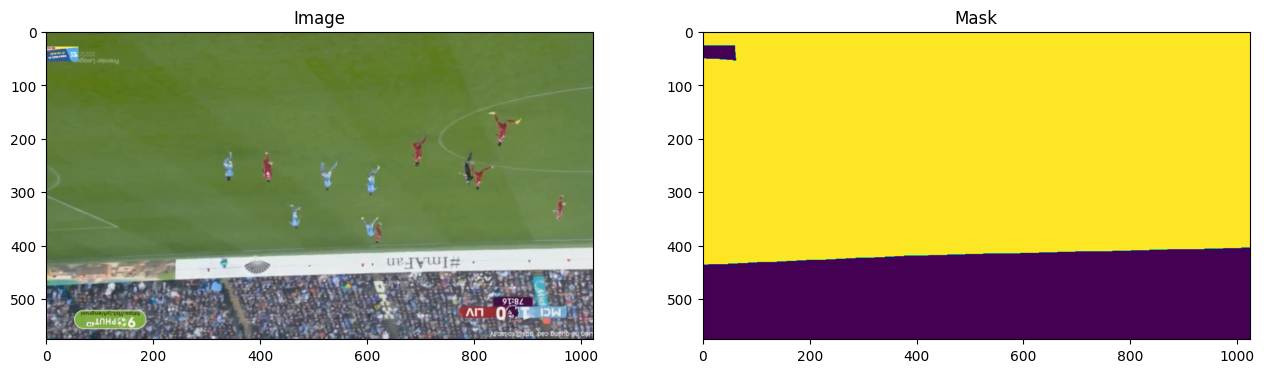

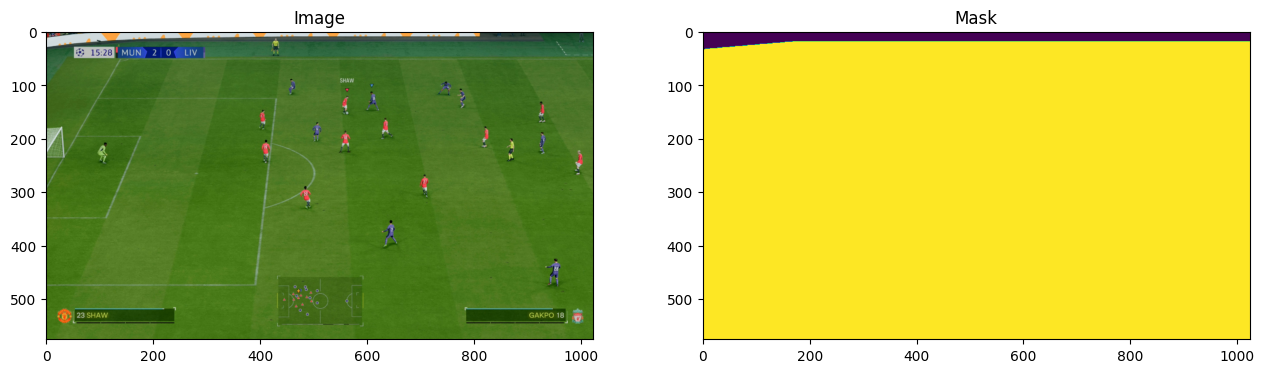

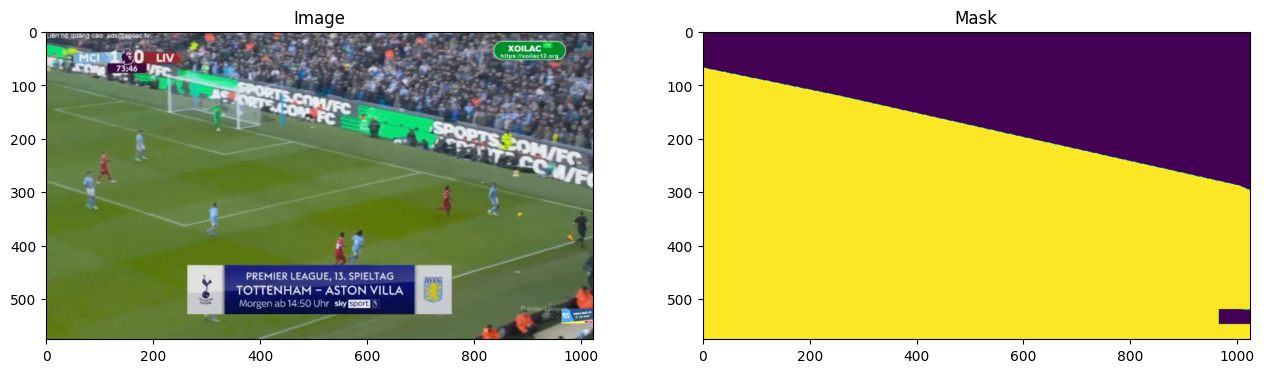

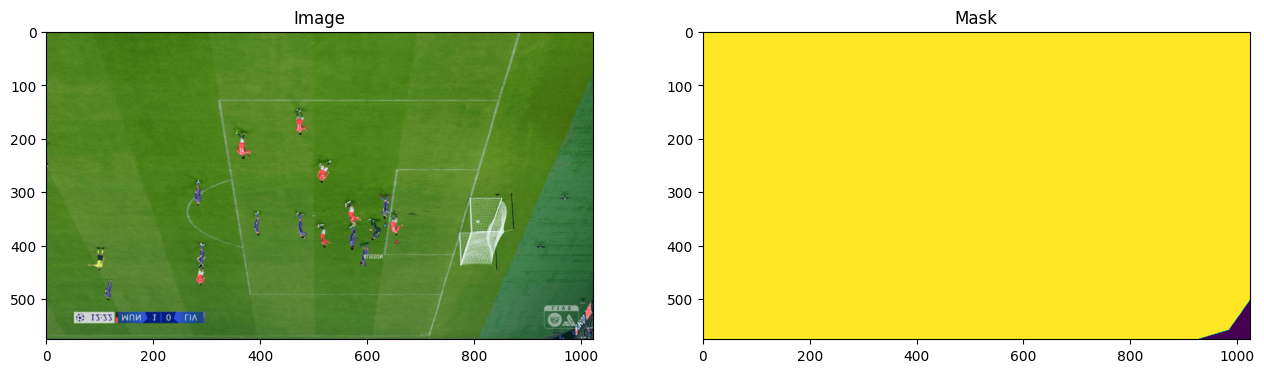

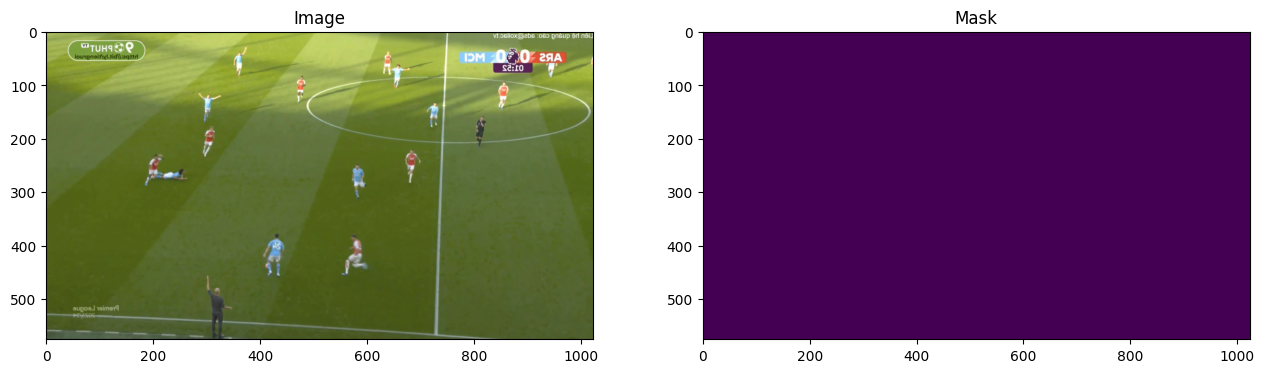

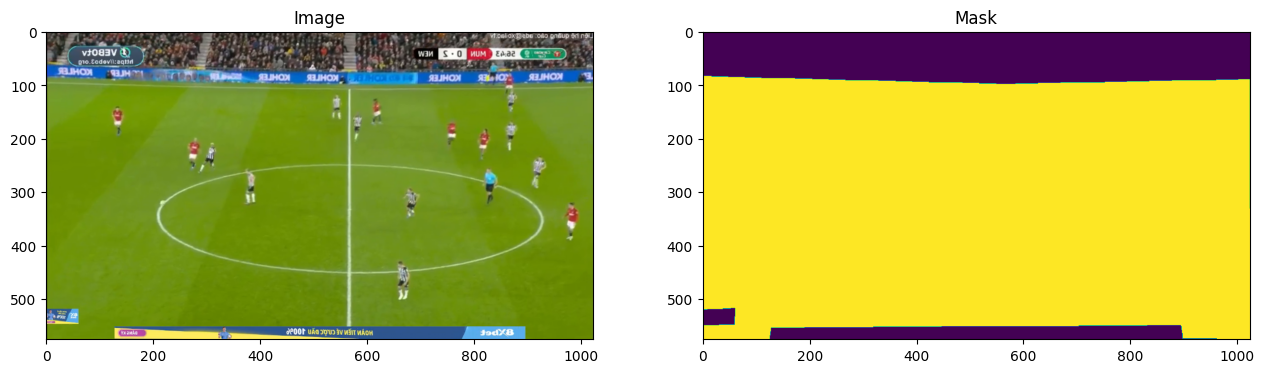

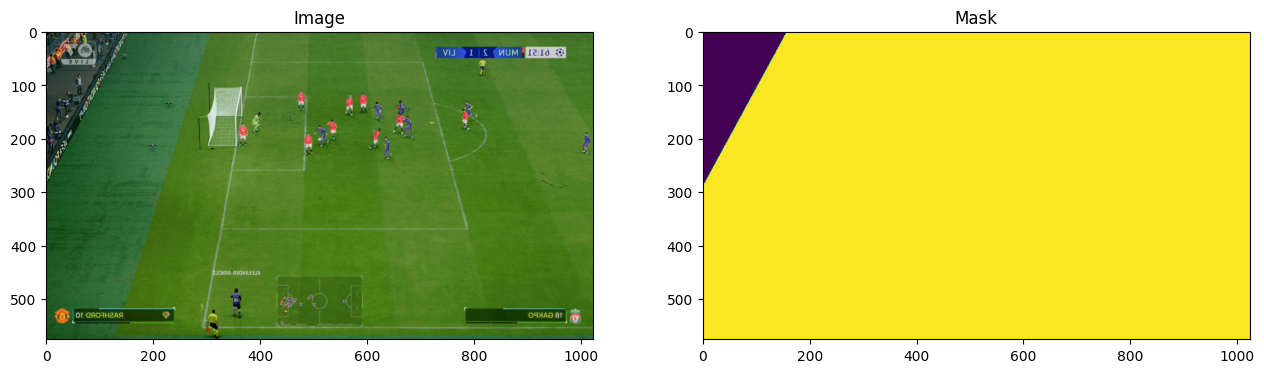

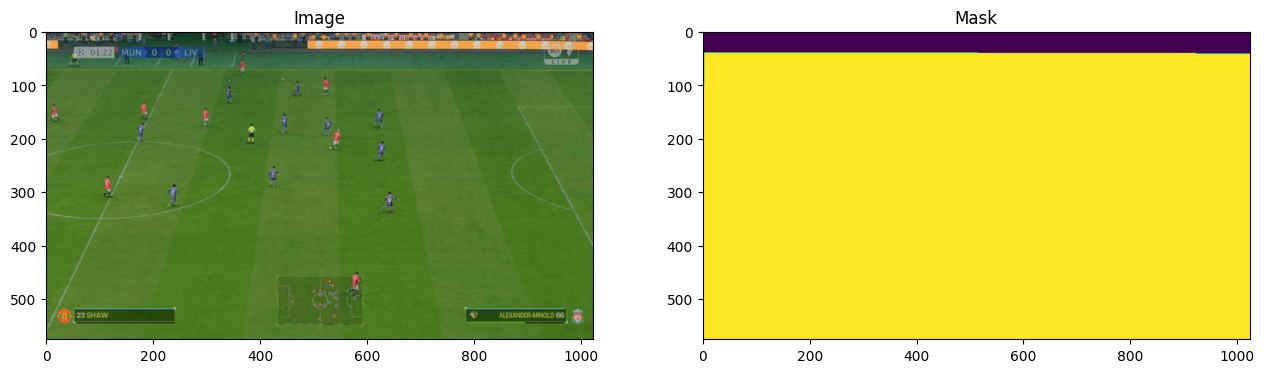

In [4]:
image_folder = os.path.join(merge_dest_path, "images")
annotation_file = os.path.join(merge_dest_path, "annotations", "instances_default.json")

transform = albumentations.Compose([
        albumentations.Resize(576, 1024),
        albumentations.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
        albumentations.HorizontalFlip(p=0.5),
        albumentations.VerticalFlip(p=0.5)
        ])

dataset = PitchDataset(image_folder=image_folder, annotation_file=annotation_file
                       , transform=transform)
data_loader = DataLoader(dataset, batch_size=16, shuffle=True)
images, masks = next(iter(data_loader))

for i in range(8):
    plt.figure()
    plt.subplot(1, 3, 1)
    plt.imshow(images[i].permute(1, 2, 0).numpy())
    plt.title("Image")
    plt.subplot(1, 3, 2)
    plt.imshow(masks[i].permute(1, 2, 0).numpy().astype(np.int32)*255)
    plt.title("Mask")


### Train model

In [5]:
train = False
if train:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PitchSegmentationModel().to(device)
    print(device)

    criterion = iou_loss
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    average_loss_list = []
    scheduler = lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.01)

    epochs = 20
    model.train()
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for inputs, targets in tqdm(data_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        average_loss = total_loss / len(data_loader)
        average_loss_list.append(average_loss)
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {average_loss}')

    plt.figure()
    plt.plot(range(1, epochs+1), average_loss_list, label='loss')
    plt.yscale("log")
    plt.title("Training Loss")
    plt.legend()

    model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
    model_name = 'pitch_segmentation'
    torch.save(model.state_dict(), os.path.join(model_path, model_name))


cuda


  0%|          | 0/39 [00:00<?, ?it/s]

000000001969.png
000000000080_1.png
000000000143.png
000000000005_2.png
000000000597.png
000000000508.png
000000000031.png
000000000226_2.png
000000000001.png
000000000452.png
000000002712.png
000000000242.png
000000000171.png
000000001795.png
000000000296_2.png
000000000273_dup.png


  3%|▎         | 1/39 [00:02<01:25,  2.24s/it]

000000000722.png
000000000070_2.png
000000000128_2.png
000000000621.png
000000001917.png
000000000131.png
000000000082_3.png
000000000052_dup.png
000000000118_1.png
000000001344.png
000000000372.png
000000000067.png
000000000098.png
000000000016.png
000000000170.png
000000000034.png


...

000000000077_2.png
000000000407.png
000000000026_1.png
000000000506.png
000000000003.png
000000000066_2.png
000000000168.png
000000000007_2.png
000000000332_dup.png
000000000187.png
000000000901.png
000000000147.png
000000000286.png
000000000168_2.png
000000000468.png
000000000413.png


 21%|██        | 8/39 [00:06<00:19,  1.59it/s]

000000000166_2.png
000000000198.png
000000000264.png
000000000331.png
000000000063.png
000000000204.png
000000000340_2.png
000000000055.png
000000000073.png
000000000186.png
000000000315.png
000000000054.png
000000000223.png
000000000130.png
000000000143_2.png
000000000365.png


 23%|██▎       | 9/39 [00:06<00:17,  1.69it/s]

000000000312.png
000000000107_dup.png
000000000119.png
000000000024.png
000000002638.png
000000000227.png
000000000194.png
000000000017_2.png
000000000033_dup.png


### Inference

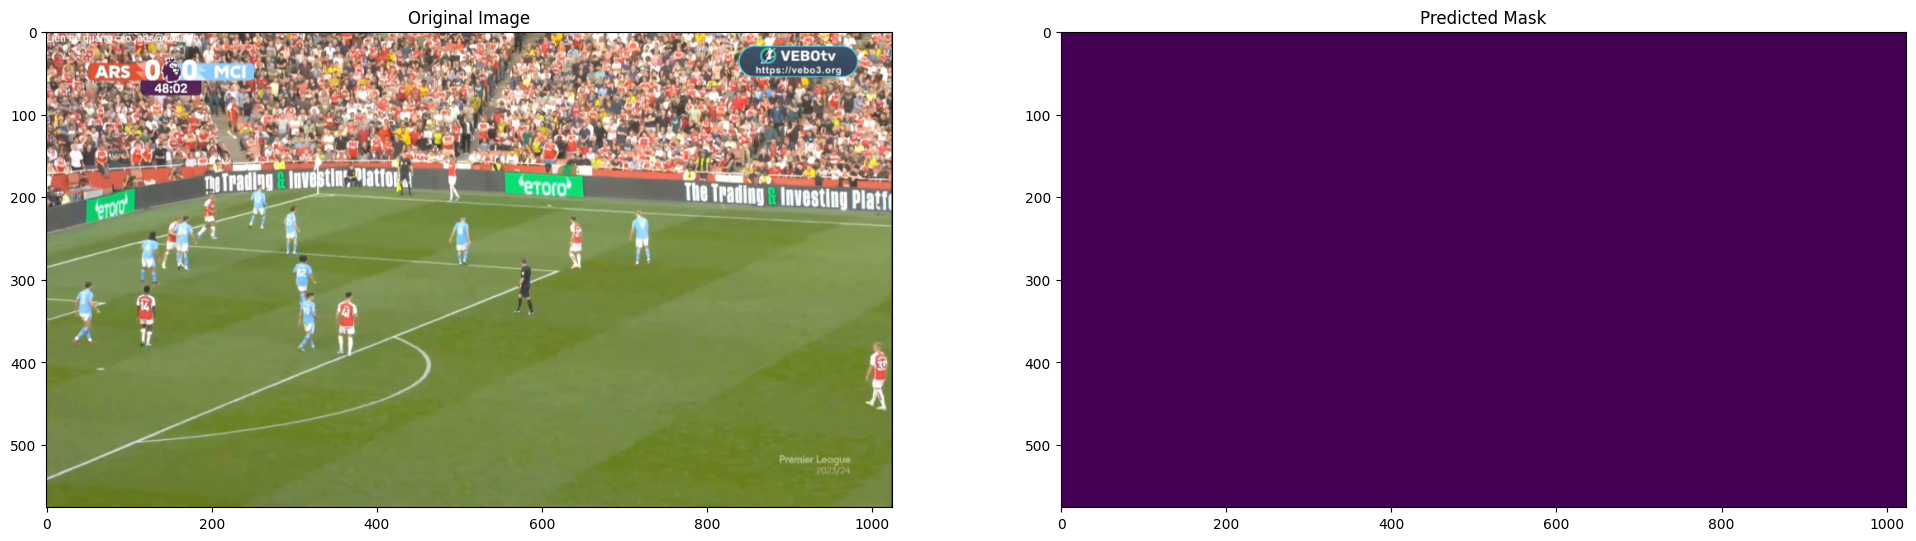

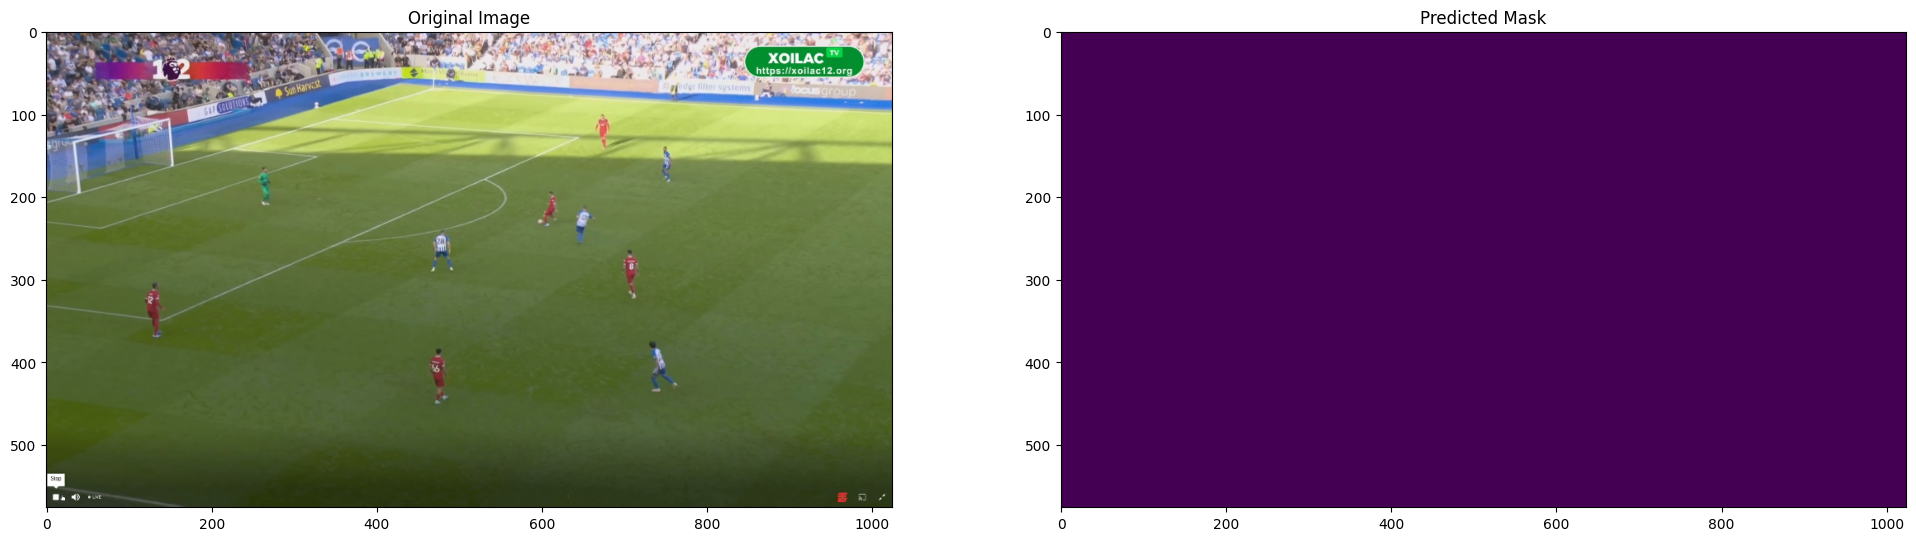

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
model_name = 'pitch_segmentation'
model_path = os.path.join(model_path, model_name)

vid_name = 'real_test'
images_path = os.path.join(data_path, 'images' + '/' + vid_name)

device = "cuda" if torch.cuda.is_available() else "cpu"

for image_name in sorted(os.listdir(images_path))[:20:10]:
    image_path = os.path.join(images_path, image_name)#sorted(os.listdir(images_path))[8])
    rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)  
    pitch_segment_by_dl_model(rgb_image, model_path, visualize=True, device=device)
